In [43]:
!pip install matplotlib-venn wordcloud

In [44]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

np.random.seed(613)
 

In [45]:

tips = sns.load_dataset("tips")
print(tips)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


<Axes: xlabel='total_bill', ylabel='tip'>

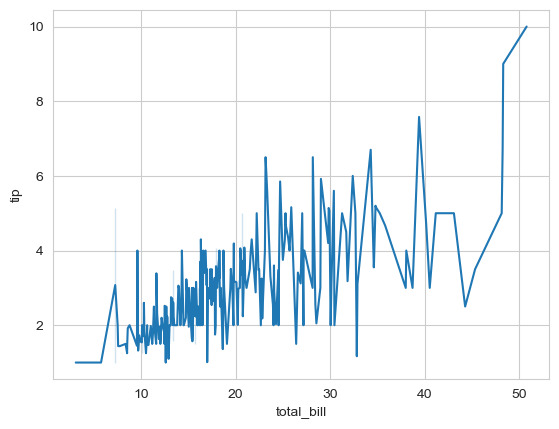

In [47]:
sns.lineplot(data=tips,       # choose  dataset
                x='total_bill',  # define  x variable
                y='tip')         # define  y variable
 

<Axes: xlabel='total_bill', ylabel='tip'>

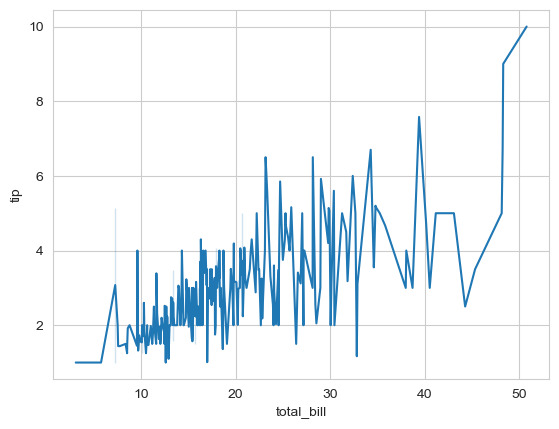

In [52]:

sns.set_style('whitegrid') # there are other styles, 'darkgrid', 'ticks', etc
# sns.set_style('ticks') # there are other styles, 'white', 'ticks', etc

sns.lineplot(data=tips,       # choose dataset
                x='total_bill',  # define x variable
                y='tip')         # define y variable

[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

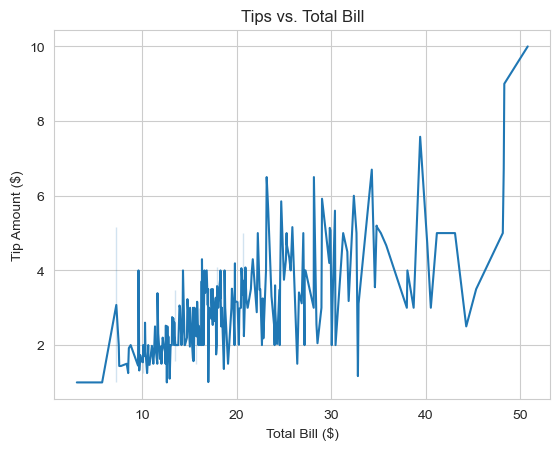

In [53]:
sns.set_style('whitegrid')  # set the style of the plot

tipgraph = sns.lineplot(data=tips,
                    x='total_bill',
                    y='tip')

tipgraph.set(title='Tips vs. Total Bill',
                 xlabel='Total Bill ($)',
                 ylabel='Tip Amount ($)')
 

[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

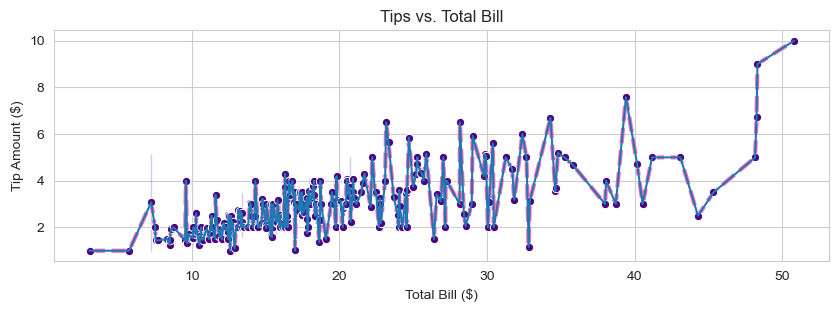

In [58]:


sns.set_style('whitegrid')  # set the style of the plot

fig = plt.subplots(figsize=(10, 3))

tipgraph = sns.lineplot(data=tips,
                    x='total_bill',
                    y='tip',
                    color = 'hotpink',
                    linestyle = '--',
                    linewidth = 3,
                    marker = 'o',
                    markerfacecolor = 'indigo')

tipgraph = sns.lineplot(data=tips,
                    x='total_bill',
                    y='tip')

tipgraph.set(title='Tips vs. Total Bill',
                 xlabel='Total Bill ($)',
                 ylabel='Tip Amount ($)')

[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

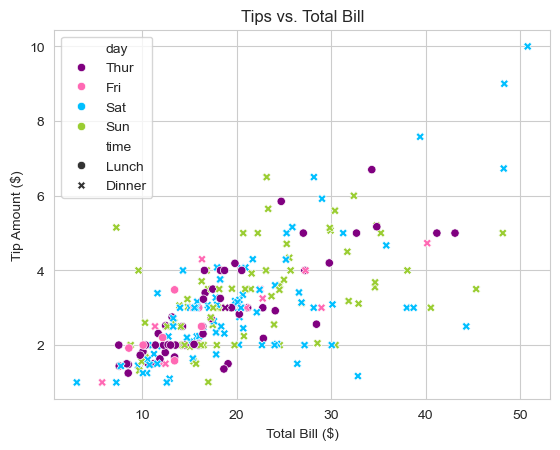

In [59]:


tipgraph = sns.scatterplot(data=tips, x='total_bill',
                             y='tip', 
                             style = 'time', 
                             hue = 'day',
                             palette = ['purple',
                             'hotpink', 'deepskyblue',
                             'yellowgreen'])

tipgraph.set(title='Tips vs. Total Bill',
                 xlabel='Total Bill ($)',
                 ylabel='Tip Amount ($)')
 

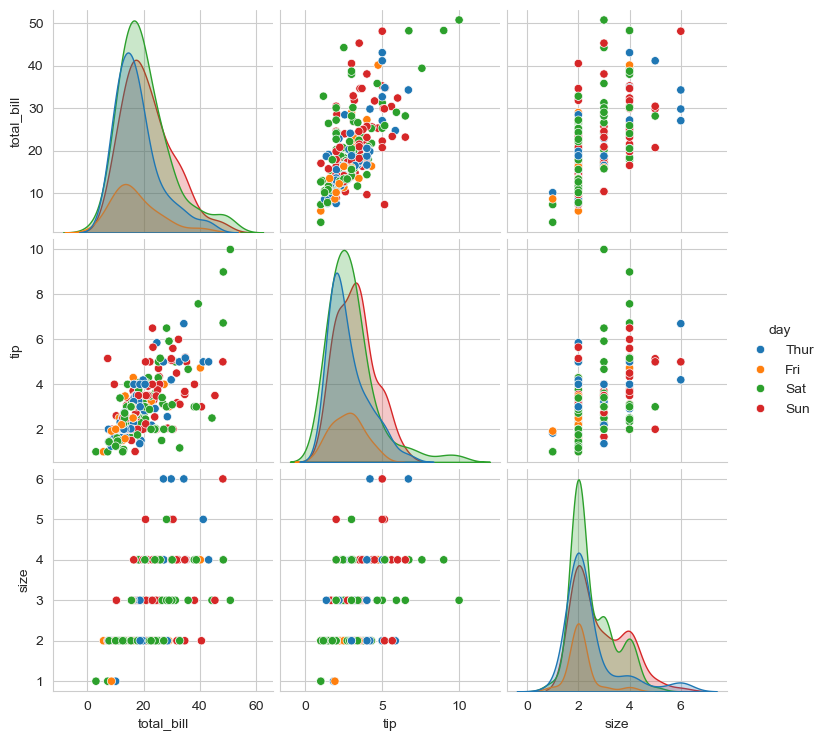

In [60]:
sns.pairplot(
      data = tips,
hue = 'day')

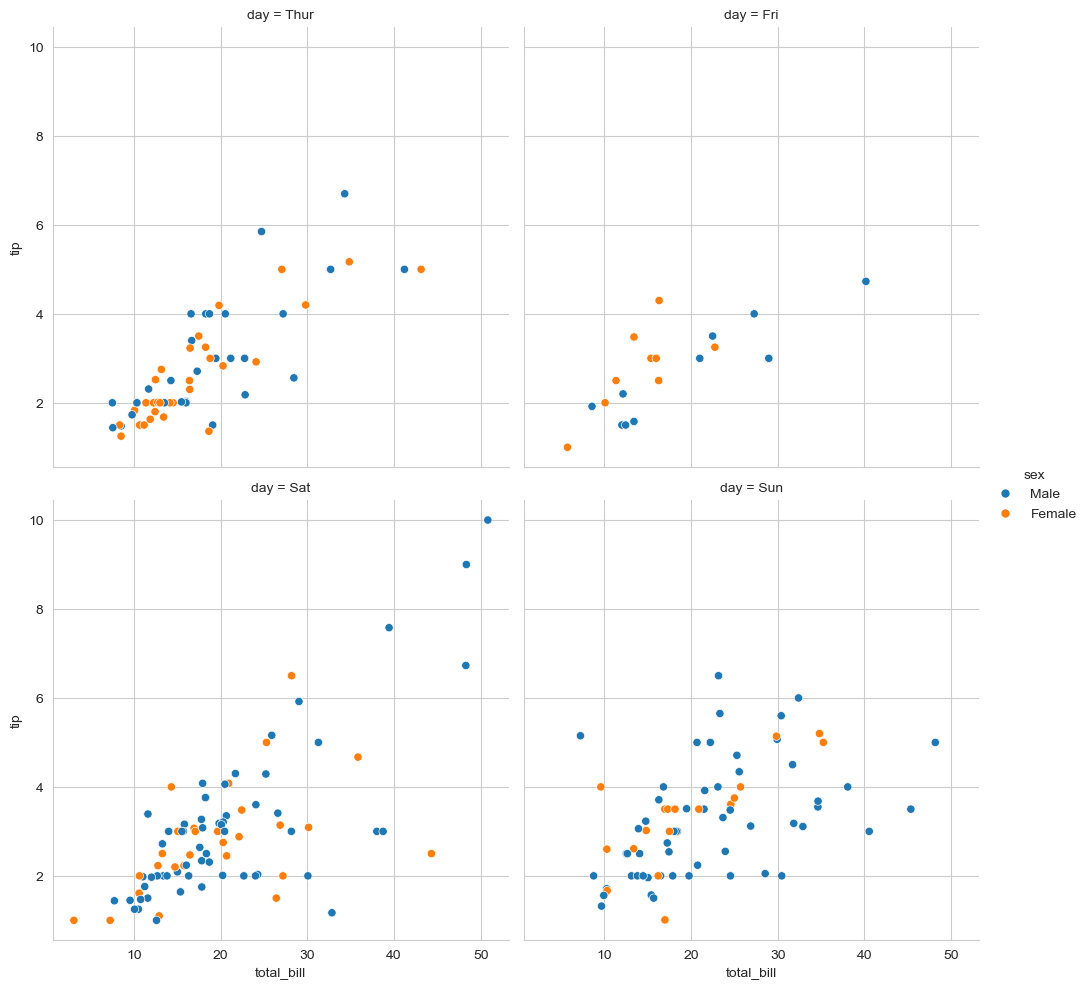

In [61]:
daysplot = sns.relplot(
            data=tips,
            x="total_bill",
            y="tip",
            hue="sex",
            col="day",
            kind="scatter",
            col_wrap=2)

In [62]:
import plotly.graph_objects as go     # 'go' is 'graph objects’

x1 = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y1 = np.array([110, 180, 240, 99, 220])


In [64]:
graph = go.Figure() # create a figure object

graph.add_trace(go.Bar(x=x1, y=y1)) # add a bar trace to the figure

graph.update_layout(
         title="Pirate Scores",
         xaxis_title="Pirates",
         yaxis_title="Score")

graph.show()  # display the graph

In [ ]:
# graph.write_html("../../folders/pirategraph.html")
 

In [65]:
graph = go.Figure()
graph.add_trace(go.Scatter(x=x1, y=y1, 
                        mode='markers',    # we want points for the scatter plot
                        marker=dict(size = 15, 
                        color='hotpink',  # marker color
                        opacity = 1,  # marker opacity
                        line = dict(
                            width = 5, color = 'purple'  # marker border
))))

graph.update_layout(
    title='Interactive Pirate Plot',
    xaxis_title='Pirates',
    yaxis_title='Scores',
    width=500, height=500)

In [66]:
from wordcloud import WordCloud

# it is important that it is raw
df = pd.read_csv("https://raw.githubusercontent.com/prasertcbs/basic-dataset/master/movie_quotes.csv",
on_bad_lines='skip')
df
 

,quote,movie,type,year
0,"Do, or do not. There is no try.",Star Wars: Episode V - The Empire Strikes Back,movie,1890
1,Listen to them. Children of the night. What mu...,Dracula,movie,1931
2,It's alive! It's alive!,Frankenstein,movie,1931
3,"Oh, no, it wasn't the airplanes. It was Beauty...",King Kong,movie,1933
4,"Magic Mirror on the wall, who is the fairest o...",Snow White and the Seven Dwarves,movie,1937
...,...,...,...,...
727,I didn't know if you were lost. Stick with me....,Us,movie,2019
728,This guy's awesome! He's holding his own while...,Dragon Ball Super: Broly,movie,2019
729,"Murder is murder, it don’t matter who you are.",Black and Blue,movie,2019
730,You know what a lion is? A lion is a strong an...,Between Two Ferns: The Movie,movie,2019


(-0.5, 399.5, 199.5, -0.5)

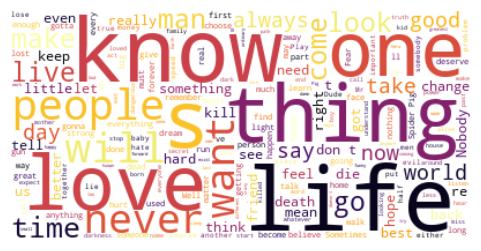

In [71]:
# join all our text from each row from our quote column into a string
text = " ".join(each for each in df.quote) # this is a list comprehension that joins all the quotes into one string

# generate our wordcloud image
wordcloud = WordCloud(background_color="white",
colormap = 'inferno').generate(text) 

# use matplotlib syntax to put our image in a figure
fig, ax = plt.subplots(figsize=(7, 3))
ax.imshow(wordcloud,                  # imshow does the work of putting our image in the axes
        interpolation='bilinear')   # this line helps smooth, tidy our image
ax.axis("off")

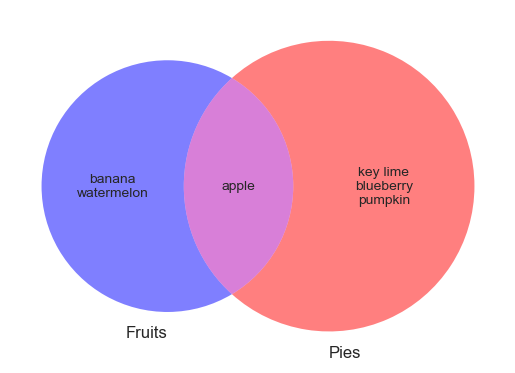

In [ ]:
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted

A = set(["apple", "banana", "watermelon"])
B = set(["pumpkin", "blueberry", "apple", "key lime"])


diagram = venn2([A, B],
                    set_labels = ('Fruits', 'Pies'),
                    set_colors=("blue", "red"),
                    alpha=0.5) # set the transparency of the circles

# we want the names of the elements in the circles, not the numbers
diagram.get_label_by_id("10").set_text("\n".join(A - B)) # left circle label, 10 binary code means only in A

diagram.get_label_by_id("11").set_text("\n".join(A & B)) # intersection label, 11 binary code means in both A and B

diagram.get_label_by_id("01").set_text("\n".join(B - A)) # right circle label, 01 binary code means only in B

plt.show()